In [1]:
import matplotlib.pyplot as plt
import numpy as np
import uproot
import pandas as pd
from matplotlib.backends.backend_pdf import PdfPages

#open root file
#df = uproot.open(
 #   "/volatile/clas12/cooperb/SULI/pid_training_test.root:PhysicsEvents"
#).arrays(library="pd")
cols = ["pid", "mc_matching_pid", "p", "theta", "beta", "chi2pid", "rich_RQ", "vz"]
df = uproot.open("/volatile/clas12/cooperb/SULI/pid_training_v2.root:PhysicsEvents").arrays(cols, library="pd")
direct ="/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/ConfusionMatrix/"
allPlots=[]

In [2]:
#creates a list of matching events (excludes events that failed matching)
matched = df[df["mc_matching_pid"] != -9999].copy()

In [3]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the matching pid as a histogram
ax2.hist(matched["mc_matching_pid"].clip(-2212, 2212), bins=100, histtype="step", density=True)
ax2.set_xlabel("mc matching pid"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(-2212, 2212, 10))
fig.tight_layout()
fig.savefig(direct+"matchedPIDs.png", dpi=150)
plt.close(fig)

In [4]:
fig, ax2 = plt.subplots(figsize=(7, 5)) #plots just the True pid as a histogram
ax2.hist(matched["pid"].clip(-2212, 2212), bins=100, histtype="step", density=True)
ax2.set_xlabel("pid"); ax2.set_ylabel("Density");
ax2.set_xticks(np.linspace(2212, 2212, 10))
fig.tight_layout()
fig.savefig(direct+"PIDs.png", dpi=150)
plt.close(fig)


In [5]:
# plots the confusion matrix with all generated particles (K- and Pi- included)
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))& (matched["mc_matching_pid"]!='All')]
top_truths = subset["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset["pid"],
    subset["mc_matching_pid"].where(subset["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)

print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2, 3])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([-321, -211, 211, 321])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
fig.colorbar(im, ax=ax2)
fig.savefig("figures/ALLGENconfuseMatrix.png", dpi=150)
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid     211    321     2212
pid                                    
211              1376958   6192    4928
321                62442  99748    2771
2212               24693   4129  991088
(3, 3)



Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211     321    2212      All
pid                                              
211              1376958    6192    4928  1388078
321                62442   99748    2771   164961
2212               24693    4129  991088  1019910
All              1464093  110069  998787  2572949
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211        321        2212
pid                                             
211              99.198892   0.446084   0.355023
321              37.852583  60.467626   1.679791
2212              2.421096   0.404840  97.174064
(3, 3)


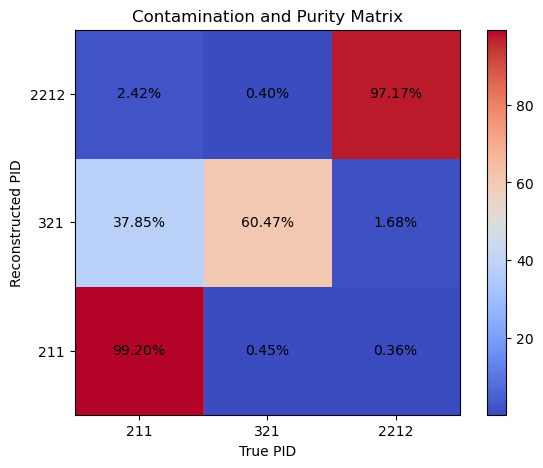

In [6]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    for j in contam.columns:
        contam.loc[i, j] *= 100/contam2.loc[i, "All"]
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([211, 321, 2212])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Contamination and Purity Matrix")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
fig.savefig(direct+"PCMatrix.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211     321    2212      All
pid                                              
211              1376958    6192    4928  1388078
321                62442   99748    2771   164961
2212               24693    4129  991088  1019910
All              1464093  110069  998787  2572949
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211      321       2212
pid                                          
211              1376958.0   6192.0    4928.0
321                62442.0  99748.0    2771.0
2212               24693.0   4129.0  991088.0
(3, 3)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211      321       2212
pid                                          
211              1376958.0   6192.0    4928.0
321                62442.0  99748.0    2771.0
2212               24693.0   4129.0  991088.0
(3, 3)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid       211      

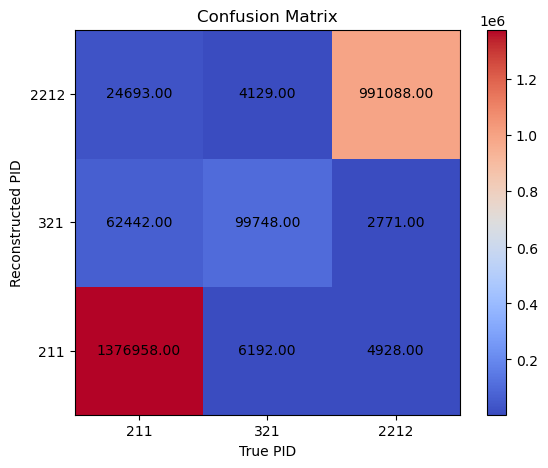

In [7]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
    print(contam)
    print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([211, 321, 2212])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Confusion Matrix")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
#fig.savefig(direct+"figures/confuseMatrixALT.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)


Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211     321    2212      All
pid                                              
211              1376958    6192    4928  1388078
321                62442   99748    2771   164961
2212               24693    4129  991088  1019910
All              1464093  110069  998787  2572949
(4, 4)

Contamination matrix (EB pid × MC-truth pid):
mc_matching_pid      211       321       2212
pid                                          
211              0.940485  0.056256  0.004934
321              0.042649  0.906232  0.002774
2212             0.016866  0.037513  0.992292
(3, 3)


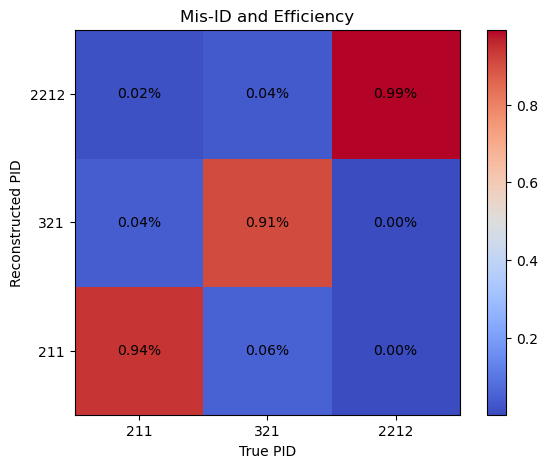

In [8]:
#plots confusion matrix with only kaons, pions and protons
subset = matched[((matched["mc_matching_pid"] == 211) | (matched["mc_matching_pid"] == 321) | (matched["mc_matching_pid"]==2212))]
subset2 = subset[(subset["pid"]!=-211)&(subset["pid"]!=-321)]
top_truths = subset2["mc_matching_pid"].value_counts().head(8).index
contam = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=False,
)
contam2 = pd.crosstab(
    subset2["pid"],
    subset2["mc_matching_pid"].where(subset2["mc_matching_pid"].isin(top_truths), other="other"),
    margins=True,
)
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam2)
print(contam2.shape)


contam = contam.astype(float)
for i in contam.index:
    for j in contam.columns:
        contam.loc[i, j] *= 1/contam2.loc["All", j]
print("\nContamination matrix (EB pid × MC-truth pid):") #these three lines are for checking that the matrix is correct
print(contam)
print(contam.shape)

fig, ax2 = plt.subplots(figsize=(7, 5))
ax2.set_xticks([0, 1, 2])
ax2.set_yticks([0, 1, 2])
ax2.set_xticklabels([211, 321, 2212])
ax2.set_yticklabels([211, 321, 2212])
ax2.set_xlabel("True PID")
ax2.set_ylabel("Reconstructed PID")
ax2.set_title("Mis-ID and Efficiency")
im = ax2.imshow(contam, cmap='coolwarm', origin='lower')
for i in range(contam.shape[0]):
    for j in range(contam.shape[1]):
        ax2.text(
            j, i,
            f"{contam.iloc[i, j]:.2f}%",
            ha="center",
            va="center"
        )
fig.colorbar(im, ax=ax2)
fig.savefig(direct+"EMMatrix.png", dpi=150)
plt.show()
allPlots.append(fig)
plt.close(fig)

In [9]:
with PdfPages("/work/clas12/CooperBe/Argonne2026/suli2026_pid/figures/ConfusionMatrix/" + "AllMatrix.pdf") as pdf:
    for plot in allPlots:
        pdf.savefig(plot)